In [1]:
pip install imbalanced-learn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)
from imblearn.over_sampling import SMOTE

In [8]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [9]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [10]:
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)
from imblearn.over_sampling import SMOTE

# Assuming 'df' is your loaded dataset
# 1. Handle missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# 2. Encode categorical variables
le = LabelEncoder()
categorical_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# 3. Define Features (X) and Target (y)
# Drop 'customerID' before defining X
X = df.drop(['Churn', 'customerID'], axis=1)
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
# Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train) # Random Forest doesn't strictly require scaling


RandomForestClassifier(random_state=42)

In [19]:
# Get predictions
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# Print Metrics
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_preds))
print("\nClassification Report:\n", classification_report(y_test, rf_preds))
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_probs):.2f}")


Confusion Matrix:
 [[932 101]
 [191 183]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC Score: 0.81


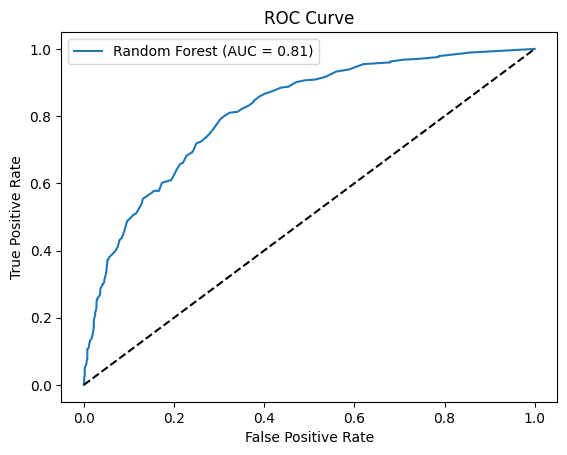

In [20]:
fpr, tpr, thresholds = roc_curve(y_test, rf_probs)
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_probs):.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Diagonal dashed line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


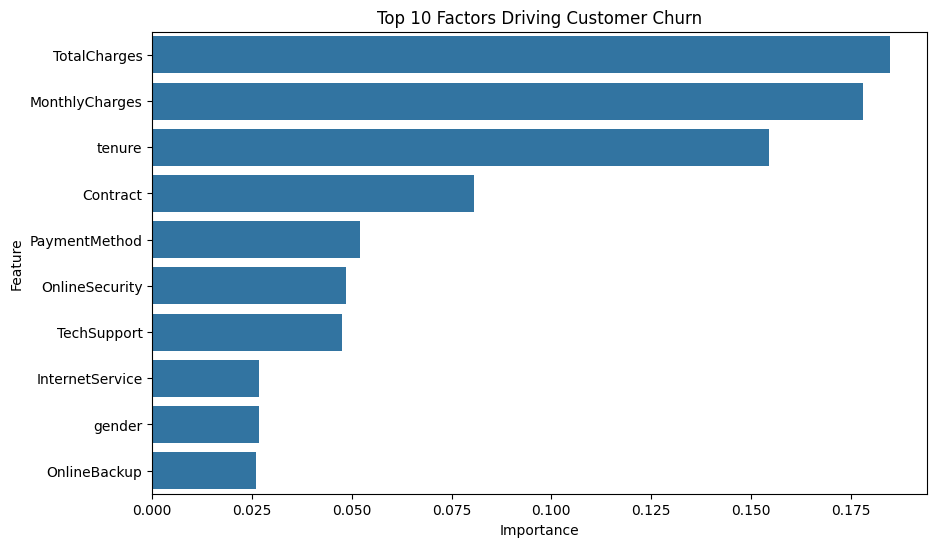

In [21]:
# Extract and plot feature importance
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Factors Driving Customer Churn')
plt.show()


In [24]:
import joblib
# Save the Random Forest model to a file
joblib.dump(rf_model, 'customer_churn_rf_model.pkl')

# Save the scaler to a file (crucial for preprocessing future new data)
joblib.dump(scaler, 'churn_scaler.pkl')

print("Model and Scaler saved successfully!")


# Load the saved model and scaler
loaded_model = joblib.load('customer_churn_rf_model.pkl')
loaded_scaler = joblib.load('churn_scaler.pkl')

# Example: New customer data (must match the exact columns of X)
# Make sure to preprocess this new data just like you did during training
new_customer_pred = loaded_model.predict(X_test.iloc[0:1])
new_customer_proba = loaded_model.predict_proba(X_test.iloc[0:1])[:, 1]

print(f"Prediction (1=Churn, 0=Stay): {new_customer_pred[0]}")
print(f"Probability of Churn: {new_customer_proba[0]*100:.2f}%")



Model and Scaler saved successfully!
Prediction (1=Churn, 0=Stay): 0
Probability of Churn: 0.00%
